# Configuración básica y carga de datos

In [ ]:
import sys
from pathlib import Path
from IPython.display import display, Image
import ipywidgets as widgets
import seaborn as sns
import pandas as pd

# Rutas
PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "data" / "Results"
SELECTED_DIR = DATA_PROCESSED / "selected"
EDGE_FILES = [
    DATA_PROCESSED / "edgeData_scen1.csv",
    DATA_PROCESSED / "edgeData_scen2.csv",
]

NET_FILE = DATA_RAW / "simulation" / "algeciras.net.xml"
NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"


sys.path.append(str(PROJECT_ROOT))

from src.milp_solve import load_milp_inputs, solve_sensor_placement
from src.evaluation import compute_flow_coverage
from scripts import make_sensor_pois
from src.evaluation import compare_milp_vs_ga

# Cargar milp_inputs (si no lo tienes ya cargado)
milp_inputs = load_milp_inputs()



# Cargamos milp_inputs ya preprocesado
milp_inputs = load_milp_inputs()

print("Claves disponibles en milp_inputs:", milp_inputs.keys())
print("Ejemplo flows:")
display(milp_inputs["flows"].head())
print("Ejemplo edges:")
display(milp_inputs["edges"].head())

Claves disponibles en milp_inputs: dict_keys(['flows', 'edges', 'nodes', 'entry_nodes', 'exit_nodes', 'O', 'D', 'M'])
Ejemplo flows:


,scenario,edge_id,tau,begin,end,flow_veh_s,flow_veh_h
0,scen1,-1097680628#0,0,0.0,60.0,0.000000,0.0
1,scen1,-1108932288#2,0,0.0,60.0,0.016667,60.0
2,scen1,-1108932289#0,0,0.0,60.0,0.033333,120.0
3,scen1,-1108932289#1,0,0.0,60.0,0.016667,60.0
4,scen1,-1312203992,0,0.0,60.0,0.000000,0.0


Ejemplo edges:


,edge_id,from_node,to_node
0,-1097680628#0,6380710388,288435676
1,-1108932288#0,12145934094,6295741084
2,-1108932288#1,12145934075,12145934094
3,-1108932288#2,10146578305,12145934075
4,-1108932289#0,5244158193,10146578306


# Re-ejecutar preprocesamiento completo

In [ ]:
from src import preprocessing


print("Usando edgeData:")
for p in EDGE_FILES:
    print("  -", p)

print("Usando red:", NET_FILE)

milp_inputs = preprocessing.construir_milp_inputs(
    edgeData_paths=EDGE_FILES,
    net_path=NET_FILE,
    processed_dir=DATA_PROCESSED,
)

print("\nPreprocesamiento completado. milp_inputs.pkl actualizado.")
print("Claves:", milp_inputs.keys())

# Ejecutar el MILP con B sensores

In [ ]:
from scripts.run_milp import run_milp_experiment

# Ejecutar MILP con B sensores y guardar selección en data/processed/selected
milp_run = run_milp_experiment(
    B=100,
    selection_dir=DATA_PROCESSED / "selected",
)


display(milp_run["df_cov"])

milp_run

# Ejecutar Algoritmo Genético (GA)

=== Ejecutando Algoritmo Genético para Sensores ===
CSV de entrada: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\edgeData_scen2.csv
Sistema inicializado: 93 tramos, 24 ecuaciones de conservación.
Número total de tramos (edges): 93
Iniciando Algoritmo Genético...
gen	nevals	min    	avg        
0  	50    	9.53245	4.28338e+13
1  	39    	9.53245	2.25952e+12
2  	42    	9.35674	2.4601e+11 
3  	44    	9.06973	8.59932e+10
4  	46    	9.06488	2.21152e+13
5  	39    	9.06488	2845.52    
6  	41    	8.84367	1.21923e+11
7  	45    	9.03626	1.0506e+11 
8  	37    	9.03626	2.09213e+11
9  	42    	9.03626	4841.22    
10 	36    	8.30542	2237.18    
11 	36    	8.30542	4433.15    
12 	39    	8.30542	1628.18    
13 	35    	8.30542	6.84188e+10
14 	39    	8.30542	3825       
15 	42    	8.20194	1.04366e+11
16 	43    	8.30542	4632.8     
17 	38    	7.8878 	4432.89    
18 	48    	8.30542	1.7538e+10 
19 	42    	8.30542	2633.7     
20 	34    	8.30542	2216.61    
21 	37    	8.30542	18

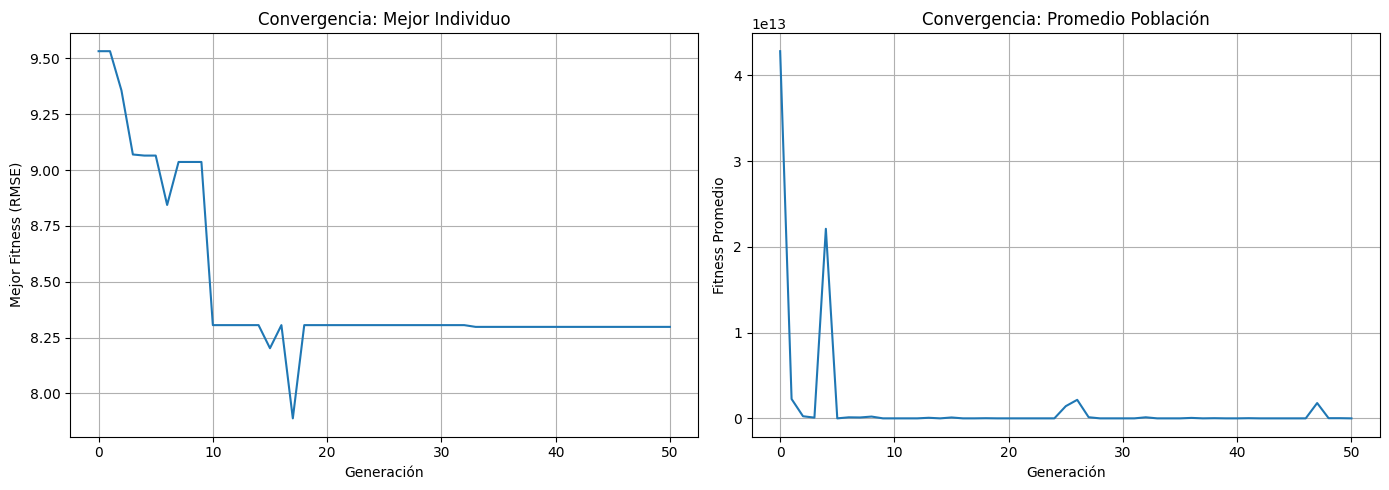

Solución visualizada. Sensores: 20. RMSE: 7.8878


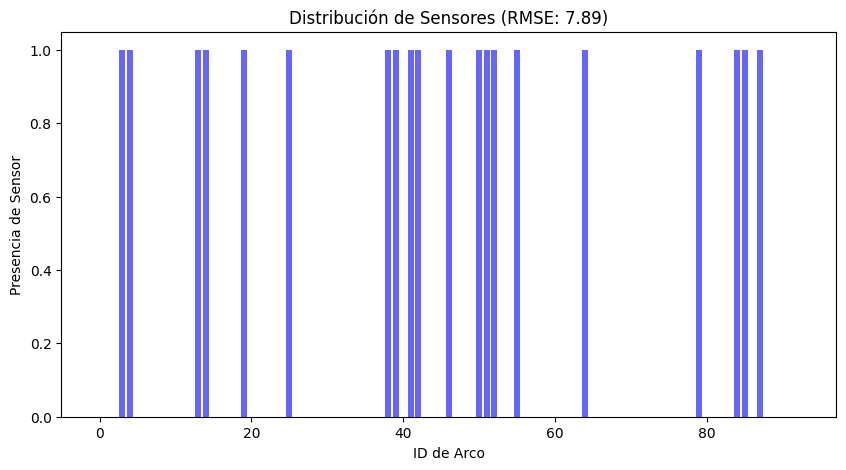

{'best': [0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0],
 'best_fitness': np.float64(7.88779995378821),
 'num_sensors': 20,
 'txt_path': WindowsPath('C:/Users/ignag/OneDrive/Documentos/TSLP/algeciras_milp_borrador/data/processed/selected/selected_edges_B20_GA.txt'),
 'png_path': WindowsPath('C:/Users/ignag/OneDrive/Documentos/TSLP/algeciras_milp_borrador/data/Results/GA_convergence_B20.png'),
 'logbook': [{'gen': 0,
   'nevals': 50,
   'min': np.float64(9.532449088040835),
   'avg': np.float64(42833769089559.19)},
  {'gen': 1,
   'nevals': 39,
   'min': np.float64(9.5324490880

In [17]:
from scripts.run_ga import run_ga_experiment

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

ga_result = run_ga_experiment(
    csv_path=DATA_PROCESSED / "edgeData_scen2.csv",
    population_size=50,
    max_generations=50,
    sensor_budget=20,   # B máximo que quieres permitir
)

ga_result

# Generación de additionals en SUMO

In [18]:
import re
from scripts import make_sensor_pois as mpois

NET_XML = DATA_RAW / "simulation" / "algeciras.net.xml"

# Calculamos los shapes una sola vez (más eficiente)
edge_shapes = mpois.cargar_shapes_net(NET_XML)
print(f"Shapes disponibles para {len(edge_shapes)} edges en {NET_XML}")

# Recorremos TODOS los selected_edges_B*.txt (MILP y GA)
for txt_path in sorted(SELECTED_DIR.glob("selected_edges_B*.txt")):
    print(f"\nProcesando {txt_path.name} ...")
    edge_ids = mpois.leer_selected_edges(txt_path)

    stem = txt_path.stem  # p.ej. "selected_edges_B25" o "selected_edges_B99_GA"

    # Buscar el patrón "_B<number>" en el nombre
    m = re.search(r"_B(\d+)", stem)
    if not m:
        print("  (no se pudo extraer B del nombre, se omite)")
        continue

    B = int(m.group(1))

    # Sufijo extra después de "_B<number>" (por ejemplo "_GA" o nada)
    suffix = stem[m.end():]  # desde donde acaba el número hasta el final

    # Construimos el nombre del .add.xml manteniendo el sufijo si existe
    #   selected_edges_B25.txt      → sensors_B25.add.xml
    #   selected_edges_B99_GA.txt   → sensors_B99_GA.add.xml
    if suffix:
        output_add = SELECTED_DIR / f"sensors_B{B}{suffix}.add.xml"
    else:
        output_add = SELECTED_DIR / f"sensors_B{B}.add.xml"

    mpois.escribir_pois(output_add, edge_ids, edge_shapes)

Shapes disponibles para 6912 edges en C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\raw\simulation\algeciras.net.xml

Procesando selected_edges_B10.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B10.add.xml

Procesando selected_edges_B13.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B13.add.xml

Procesando selected_edges_B15.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B15.add.xml

Procesando selected_edges_B20.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\processed\selected\sensors_B20.add.xml

Procesando selected_edges_B20_GA.txt ...
POIs de sensores guardados en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\proces

# Dashboard sencillo de imágenes de configuración de sensores

In [ ]:
def show_milp_image(B: int):
    """
    Muestra la imagen de resultados del MILP almacenada en:
        data/Results/{B}_MILP.png
    """
    img_path = RESULTS_DIR / f"{B}_MILP.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=15,
    max=40,
    step=5,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_milp_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

In [10]:
def show_GA_image(B: int):
    """
    Muestra la imagen de resultados del GA almacenada en:
        data/Results/{B}_GA.png
    """
    img_path = RESULTS_DIR / f"{B}_GA.png"
    if not img_path.exists():
        print(f"No se encontró la imagen {img_path}")
        return
    display(Image(filename=str(img_path)))

# Widget: deslizador para elegir B (ajusta el rango a tus valores disponibles)
B_slider = widgets.IntSlider(
    value=20,
    min=20,
    max=98,
    step=10,
    description="Sensors B:",
    continuous_update=False,
)

ui = widgets.VBox([B_slider])

out = widgets.Output()

def on_B_change(change):
    if change["name"] == "value":
        B = change["new"]
        out.clear_output()
        with out:
            print(f"Configuración de sensores para B = {B}")
            show_GA_image(B)

B_slider.observe(on_B_change, names="value")

display(ui, out)

# Llamada inicial
on_B_change({"name": "value", "new": B_slider.value})

Output()

In [6]:
df_comp = compare_milp_vs_ga(
    milp_inputs=milp_inputs,
    selected_dir=SELECTED_DIR,
    results_dir=RESULTS_DIR / "evaluation",
)

display(df_comp)

Budgets B comunes encontrados (MILP & GA): [20]

=== Comparando B = 20 ===
Figura de comparación guardada en: C:\Users\ignag\OneDrive\Documentos\TSLP\algeciras_milp_borrador\data\Results\evaluation\comparison_MILP_vs_GA_B20.png


,B,algo,scenario,total_flow_veh_h,sensed_flow_veh_h,coverage_ratio
0,20,MILP,ALL,8697120.0,39240.0,0.004512
1,20,GA,ALL,8697120.0,714900.0,0.082200


# Simulated Annealing (SA)

In [ ]:
from src.sa_algorithm import SimulatedAnnealing
from src.ga_algorithm import TrafficNetwork, save_ga_solution

# Load network
csv_path = DATA_PROCESSED / "edgeData_scen2.csv"
network = TrafficNetwork(csv_path)

budget = 20

print(f"Running SA with B={budget}...")
sa = SimulatedAnnealing(network, budget=budget, max_iter=3000, initial_temp=10000)
sa_result = sa.run(seed=42)

print("Best SA Fitness (RMSE):", sa_result['best_fitness'])

# Save solution
output_sa_path = DATA_PROCESSED / f"selected/selected_edges_B{budget}_SA.txt"
save_ga_solution(sa_result['best_solution'], network, output_sa_path)
print(f"SA Solution saved to {output_sa_path}")

# Multi-Seed Experiments & Variance Analysis

In [ ]:
from src.experiments import run_multi_seed_experiment, plot_variance_analysis
import pandas as pd

# Define seeds
seeds = [42, 10, 2023, 777, 99]
budget = 20

# Run GA
print("Running Multi-seed GA...")
df_ga = run_multi_seed_experiment(network, 'GA', budget, seeds, population_size=50, max_generations=50)

# Run SA
print("Running Multi-seed SA...")
df_sa = run_multi_seed_experiment(network, 'SA', budget, seeds, max_iter=3000)

# Combine results
df_all = pd.concat([df_ga, df_sa], ignore_index=True)

# Display results
display(df_all.groupby('algorithm')['rmse'].describe())

# Plot Variance
output_plot = RESULTS_DIR / "variance_analysis.png"
plot_variance_analysis(df_all, output_path=output_plot)